In [223]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
import numpy as np




In [224]:
df = pd.read_csv('../data/raw/sales.csv')
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


## Convertimos a datetime

In [226]:
df['date'] = pd.to_datetime(df['date'])

In [227]:
df.set_index('date', inplace=True)

In [228]:
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [229]:
ts = df['sales']
ts.index

DatetimeIndex(['2022-09-03 17:10:08.079328', '2022-09-04 17:10:08.079328',
               '2022-09-05 17:10:08.079328', '2022-09-06 17:10:08.079328',
               '2022-09-07 17:10:08.079328', '2022-09-08 17:10:08.079328',
               '2022-09-09 17:10:08.079328', '2022-09-10 17:10:08.079328',
               '2022-09-11 17:10:08.079328', '2022-09-12 17:10:08.079328',
               ...
               '2023-08-25 17:10:08.079328', '2023-08-26 17:10:08.079328',
               '2023-08-27 17:10:08.079328', '2023-08-28 17:10:08.079328',
               '2023-08-29 17:10:08.079328', '2023-08-30 17:10:08.079328',
               '2023-08-31 17:10:08.079328', '2023-09-01 17:10:08.079328',
               '2023-09-02 17:10:08.079328', '2023-09-03 17:10:08.079328'],
              dtype='datetime64[ns]', name='date', length=366, freq=None)

## ¿Cuál es el tensor de la serie temporal?

In [230]:
pd.infer_freq(ts.index)

'D'

El tensor es diario (D), ya que los datos están registrados con frecuencia diaria

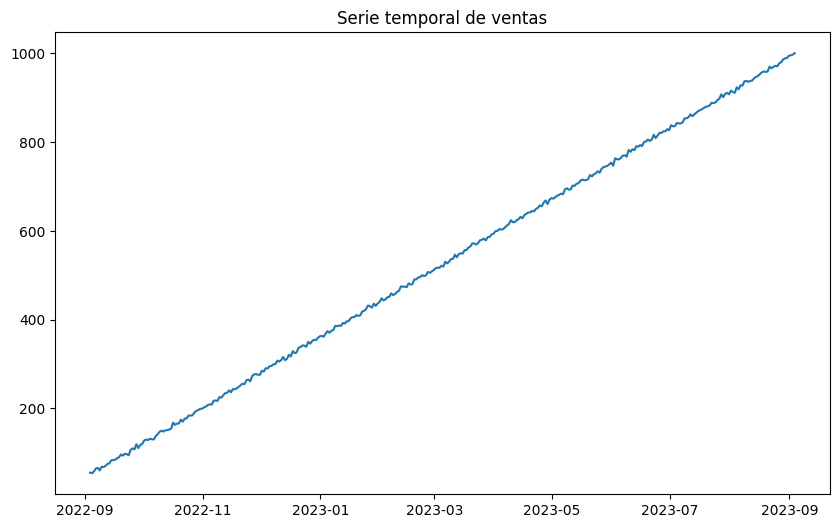

In [231]:
plt.figure(figsize=(10,6))
plt.plot(ts)
plt.title('Serie temporal de ventas')

plt.show()


# Hay tendencia, ya que la linea es creciente hacia la derecha

In [232]:
def test_stationarity(timeseries):
    print("Dickey-Fuller test results:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Dickey-Fuller test results:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

> - P-value = 0.98 La serie NO es estacionaria 

Eliminamo la tendencia.
Esto permite que:
>
> - La media se estabilice
>
> - El test ADF detecte estacionariedad

In [233]:
ts_diff = ts.diff().dropna()

ts_diff.head()

date
2022-09-04 17:10:08.079328   -1.488946
2022-09-05 17:10:08.079328    4.338482
2022-09-06 17:10:08.079328    6.389205
2022-09-07 17:10:08.079328    1.482734
2022-09-08 17:10:08.079328   -5.931768
Name: sales, dtype: float64

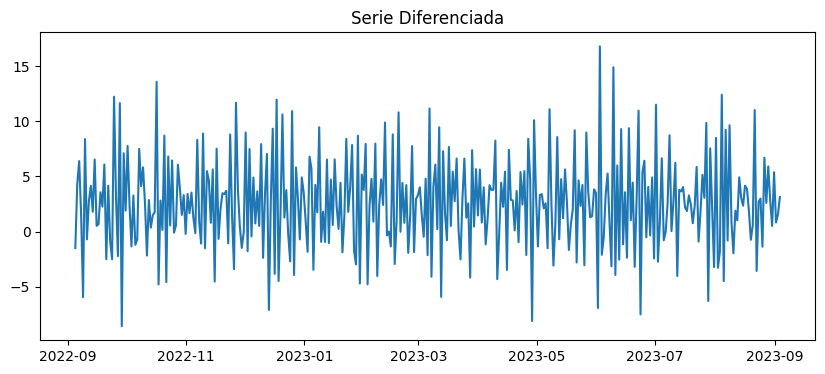

In [234]:
plt.figure(figsize=(10,4))
plt.plot(ts_diff)
plt.title('Serie Diferenciada')

plt.show()

In [235]:
test_stationarity(ts_diff)

Dickey-Fuller test results:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

P-Value 5.212954e-16

> - Observamos que la serie diferenciada es estacionaria

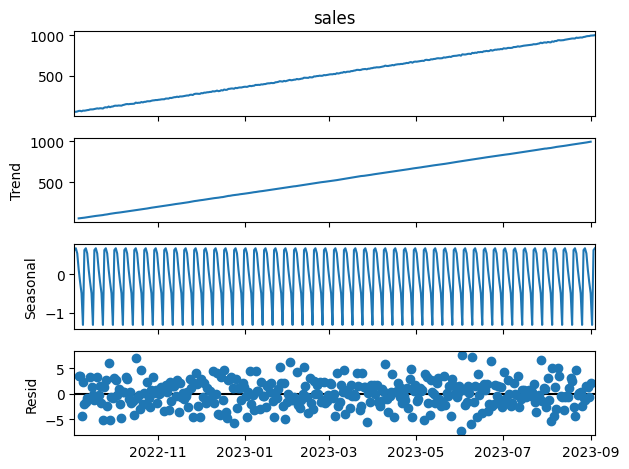

In [236]:
decomposition = seasonal_decompose(ts, model='additive')
decomposition.plot()

plt.show()

## Observaciones y Conclusiones
> 
> - Tendencia fuerte.
> 
> - Estacionalidad leve.
> 
> - Residuo cercano.

## ARIMA

Ya que hay Tendencia.

<Figure size 1000x400 with 0 Axes>

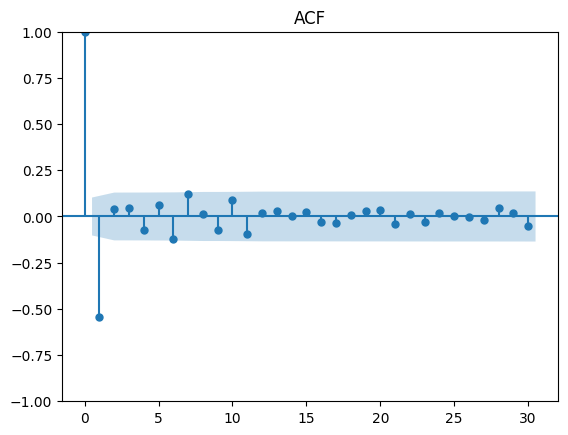

In [237]:
plt.figure(figsize=(10,4))
plot_acf(ts_diff, lags=30)
plt.title('ACF')

plt.show()

<Figure size 1000x400 with 0 Axes>

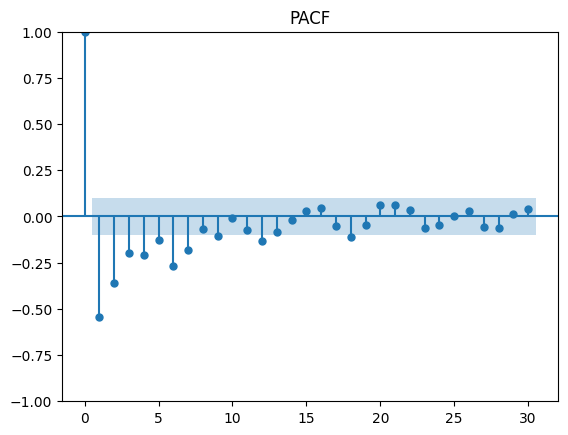

In [238]:
plt.figure(figsize=(10,4))
plot_pacf(ts_diff, lags=30, method='ywm')
plt.title('PACF')

plt.show()

## Observaciones:
>
> - ACF sugiere: 𝑞 = 1
> 
> - PACF sugiere: 𝑝 = 3

In [239]:
model = ARIMA(ts, order=(3, 1, 1))
model_fit = model.fit()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [240]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  sales   No. Observations:                  366
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -961.266
Date:                Sun, 15 Feb 2026   AIC                           1932.532
Time:                        23:22:24   BIC                           1952.032
Sample:                    09-03-2022   HQIC                          1940.281
                         - 09-03-2023                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2642      0.011     23.455      0.000       0.242       0.286
ar.L2          0.3788      0.039      9.704      0.000       0.302       0.455
ar.L3          0.3570      0.050      7.161      0.000       0.259       0.455
ma.L1         -0.9994      0.078    -12.798      0.000      -1.152      -0.846
sigma2        11.1264      0.007   1613.451      0.000      11.113      11.140
===================================================================================
Ljung-Box (L1) (Q):                   1.76   Jarque-Bera (JB):                 1.35
Prob(Q):                              0.18   Prob(JB):                         0.51
Heteroskedasticity (H):               0.95   Skew:                             0.08
Prob(H) (two-sided):                  0.78   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.19e+18. Standard errors may be unstable.
"""

## Observaciones y conslusiones:

| Modelo  | AIC  | Residuos |
| ------- | ---- | -------- |
| (1,1,1) | 2104 | Mal      |
| (2,1,1) | 1980 | Mal      |
| (3,1,1) | 1932 | Bien     |

## Predicción In-Sample

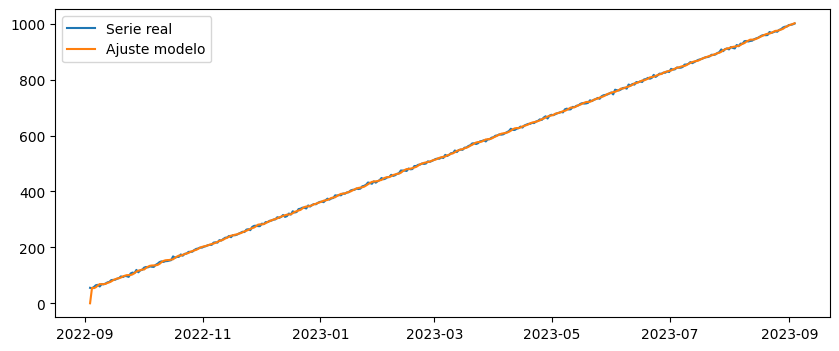

In [241]:
fitted = model_fit.fittedvalues

plt.figure(figsize=(10,4))
plt.plot(ts, label="Serie real")
plt.plot(fitted, label="Ajuste modelo")
plt.legend()

plt.show()


# El modelo sigue la tendencia

## División Train/Test

In [242]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

model = ARIMA(train, order=(3,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


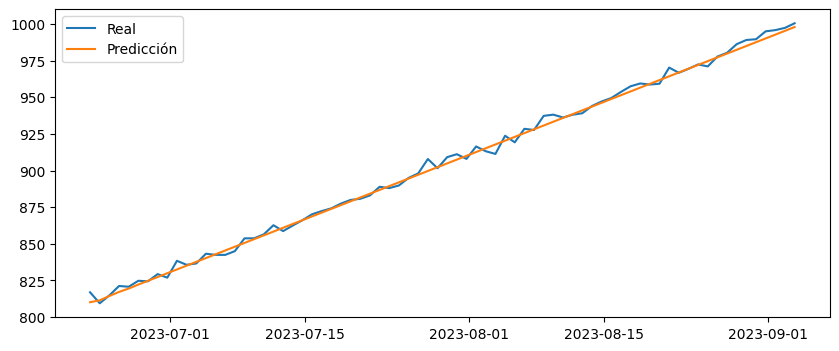

In [243]:
plt.figure(figsize=(10,4))
plt.plot(test.index, test, label="Real")
plt.plot(test.index, forecast, label="Predicción")
plt.legend()

plt.show()


## Tendencia fuerte

## METRICAS

In [244]:

mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

rmse


2.931360918285647

## Guardado


In [245]:
import pickle

with open("arima_311_model.pkl", "wb") as f:
    pickle.dump(model_fit, f)


# Conclusion
>
Tras analizar la tendencia, aplicar diferenciación y estudiar ACF y PACF, se compararon los modelos **ARIMA(1,1,1)**, **ARIMA(2,1,1)** y **ARIMA(3,1,1)**.
>
El modelo **ARIMA(3,1,1)** fue seleccionado porque presentó el menor AIC, mejores métricas predictivas y residuos sin autocorrelación, demostrando que captura mejor la estructura temporal de la serie.